# Домашнее задание 5. Градиентный бустинг


Работать будем с набором данных о грибах, в котором собраны признаки внешнего вида и среды обитания разных грибов. Ваша задача — построить модель, которая сможет определять, съедобен гриб или ядовит.

**Описание признаков**

Этот датасет составлен на основе известного набора данных с Kaggle: [Mushroom Attributes Dataset](https://www.kaggle.com/datasets/ulrikthygepedersen/mushroom-attributes)

| Признак                  | Описание                                                                                                                                                               |
| ------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| cap-texture        | текстура поверхности шляпки (a — гладкая, b — волокнистая, c — чешуйчатая, d — бархатистая, e — морщинистая, f — зернистая, g — кожистая, h — липкая, i — матовая, j — блестящая, k — сетчатая, l — пористая, m — волнистая, n — пятнистая, o — ребристая, p — шероховатая, q — плотная, r — рыхлая, s — слоистая) |
| spore-pattern      | характер распределения спор (a — равномерный, b — редкий, c — плотный, d — кольцевой, e — радиальный, f — пятнистый, g — полосчатый, h — сетчатый, i — кластерный, j — случайный, k — концентрический, l — разреженный, m — волнообразный, n — диагональный, o — смешанный) |
| stem-flexibility   | гибкость ножки гриба (a — очень жесткая, b — жесткая, c — умеренно жесткая, d — слегка гибкая, e — гибкая, f — очень гибкая, g — упругая, h — мягкая, i — ломкая, j — эластичная) |
| ring-thickness     | толщина кольца на ножке (a — тонкое, b — среднее, c — толстое) |
| cap-shape                | форма шляпки (b — колокольчик, c — конический, x — выпуклый, f — плоский, k — с бугорком, s — утопленный)                                                                |
| cap-surface              | поверхность шляпки (f — волокнистая, g — канавки, y — чешуйчатая, s — гладкая)                                                                                         |
| cap-color                | цвет шляпки (n — коричневый, b — желтовато-коричневый, c — корица, g — серый, r — зелёный, p — розовый, u — фиолетовый, e — красный, w — белый, y — желтый)            |
| gill-attachment          | тип прикрепления пластинок (a — прикреплено, d — нисходящее, f — свободное, n — зубчатое)                                                                              |
| stalk-shape              | форма ножки (e — утолщение, t — сужение)                                                                                                                               |
| veil-type                | тип завесы (p — частичная, u — универсальная)                                                                                                                          |
| veil-color               | цвет завесы (n — коричневый, o — оранжевый, w — белый, y — жёлтый)                                                                                                     |
| ring-number              | количество колец (n — нет, o — одно, t — два)                                                                                                                          |
| population               | тип популяции (a — многочисленная, c — сгруппированная, n — обычная, s — рассеянная, v — несколько, y — одиночная)                                                     |
| habitat                  | среда обитания (g — трава, l — листья, m — луга, p — тропинки, u — город, w — отходы, d — леса)                                                                        |

Каждая строка описывает один вид гриба.

**Таргет** — столбец `class`:

* `e` — съедобный гриб
* `p` — ядовитый гриб



In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import metrics

from scipy.stats import chi2_contingency
import optuna
from optuna.samplers import TPESampler

import catboost as cb
import xgboost as xgb
import lightgbm as lgb

from warnings import simplefilter
simplefilter(action='ignore')

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", 10000)

## Задание 1

Эта часть, как всегда, посвящена знакомству с данными:

* Загрузите данные, посмотрите на структуру, количество строк и столбцов.
* Проверьте наличие пропусков NaN и типы признаков, при необходимости обработайте их.
* Проверьте наличие полных дубликатов строк в данных, при необходимости удалите их.
* Присутствуют ли столбцы с ошибочными названиями? Исправьте при наличии.

Запишите наблюдения в коротком выводе.

In [2]:
"""
ВАШЕ РЕШЕНИЕ
"""

mushroom_data = pd.read_csv('mushrooms.csv')
display(mushroom_data.sample(10))

print(f'Количество строк в датасете: {mushroom_data.shape[0]}')
print(f'Количество столбцов в датасете: {mushroom_data.shape[1]}')

display(mushroom_data.info())

,cap-texture,spore-pattern,stem-flexibility,ring-thickness,cap-shape,cap-surface:%3F,cap-color,gill-attachment,stalk-shape,veil-type,veil-color,ring-number,population,habitat,class
6638,b'm',b'o',b'f',b'a',b'k',b'y',b'n',b'f',b't',b'p',b'w',b'o',b'v',b'p',b'p'
5283,b'f',b'i',b'i',b'a',b'f',b'y',b'w',b'f',b'e',b'p',b'w',b'o',b'y',b'd',b'e'
1678,b'e',b'l',b'a',b'a',b'f',b's',b'n',b'f',b't',b'p',b'w',b'o',b'a',b'g',b'e'
1731,b'e',b'f',b'j',b'c',b'x',b's',b'n',b'f',b'e',b'p',b'w',b'o',b'v',b'u',b'p'
1591,b'h',b'd',b'c',b'b',b'x',b'f',b'g',b'f',b't',b'p',b'w',b'o',b's',b'g',b'e'
3891,b'r',b'g',b'b',b'b',b'f',b'y',b'g',b'f',b't',b'p',b'w',b'o',b'v',b'd',b'e'
6486,b'd',b'b',b'f',b'c',b'f',b's',b'e',b'f',b't',b'p',b'w',b'o',b'v',b'l',b'p'
2878,b'q',b'l',b'f',b'c',b'f',b'f',b'g',b'f',b't',b'p',b'w',b'o',b'y',b'd',b'e'
7371,b's',b'o',b'g',b'c',b'k',b'y',b'n',b'f',b't',b'p',b'w',b'o',b'v',b'p',b'p'
1086,b'm',b'g',b'a',b'b',b'b',b'y',b'w',b'f',b'e',b'p',b'w',b'o',b'n',b'm',b'e'


Количество строк в датасете: 8124
Количество столбцов в датасете: 15
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   cap-texture       8124 non-null   str  
 1   spore-pattern     8124 non-null   str  
 2   stem-flexibility  8124 non-null   str  
 3   ring-thickness    8124 non-null   str  
 4   cap-shape         8124 non-null   str  
 5   cap-surface:%3F   8124 non-null   str  
 6   cap-color         8124 non-null   str  
 7   gill-attachment   8124 non-null   str  
 8   stalk-shape       8124 non-null   str  
 9   veil-type         8124 non-null   str  
 10  veil-color        8124 non-null   str  
 11  ring-number       8124 non-null   str  
 12  population        8124 non-null   str  
 13  habitat           8124 non-null   str  
 14  class             8124 non-null   str  
dtypes: str(15)
memory usage: 1.4 MB


None

In [3]:
print('Количество пропусков по столбцам:')
display(mushroom_data.isna().sum())

Количество пропусков по столбцам:


cap-texture         0
spore-pattern       0
stem-flexibility    0
ring-thickness      0
cap-shape           0
cap-surface:%3F     0
cap-color           0
gill-attachment     0
stalk-shape         0
veil-type           0
veil-color          0
ring-number         0
population          0
habitat             0
class               0
dtype: int64

In [4]:
print(f'Количество строк-дубликатов: {mushroom_data.duplicated().sum()}')
mushroom_data = mushroom_data.drop_duplicates()
print(
    'Количество строк в датасете после дедупликации:',
    mushroom_data.shape[0]
)

Количество строк-дубликатов: 0
Количество строк в датасете после дедупликации: 8124


In [5]:
# Исправление названия столбца
mushroom_data.rename(
    columns={'cap-surface:%3F': 'cap-surface'}, 
    inplace=True
)

**Вывод:**   
1 Датасет содержит 8124 записи с категориальными признаками. Всего 15 признаков.  
2 Явные пропуски в записях не обнаружены.  
3 Полных дубликатов строк в датасете не выявлено.    
4 Исправлено наименование столбца "cap-surface".

## Задание 2

Исследуем поближе категориальные признаки датасета:

* Выведите уникальные значения каждого категориального признака, просмотрите их. Есть ли в датасете скрытые пропуски и неинформативные признаки? При необходимости обработайте/удалите их.
* Приведите каждое значение к одной букве, удалив всюду кавычки и `b`.
* Изучите распределения признаков, построив для каждого `countplot`. Если есть редкие категории, предложите, что с ними лучше сделать. Заодно проверьте, присутствует ли дисбаланс классов.

Запишите все мысли в выводе.

In [6]:
"""
ВАШЕ РЕШЕНИЕ
"""

column_names = mushroom_data.columns.tolist()
for name in column_names:
    print('Наименование столбца', name)
    print(f'Количество уникальных категорий {name}: \
{mushroom_data[name].nunique()}')
    print(f'Уникальные категории {name}: ',
        *mushroom_data[name].unique(), 
        '\n')

Наименование столбца cap-texture
Количество уникальных категорий cap-texture: 19
Уникальные категории cap-texture:  b'j' b'm' b'e' b'b' b'h' b'p' b'n' b'a' b'l' b'g' b'r' b's' b'f' b'i' b'd' b'k' b'c' b'q' b'o' 

Наименование столбца spore-pattern
Количество уникальных категорий spore-pattern: 15
Уникальные категории spore-pattern:  b'i' b'g' b'c' b'f' b'a' b'j' b'd' b'm' b'o' b'e' b'b' b'n' b'h' b'l' b'k' 

Наименование столбца stem-flexibility
Количество уникальных категорий stem-flexibility: 10
Уникальные категории stem-flexibility:  b'a' b'f' b'e' b'j' b'h' b'c' b'b' b'i' b'g' b'd' 

Наименование столбца ring-thickness
Количество уникальных категорий ring-thickness: 3
Уникальные категории ring-thickness:  b'a' b'c' b'b' 

Наименование столбца cap-shape
Количество уникальных категорий cap-shape: 6
Уникальные категории cap-shape:  b'x' b'b' b's' b'f' b'k' b'c' 

Наименование столбца cap-surface
Количество уникальных категорий cap-surface: 4
Уникальные категории cap-surface:  b's' b'y

In [7]:
# Удаление неинформативного столбца veil-type
mushroom_data.drop('veil-type', axis=1, inplace=True)
print(f'Итоговое количество столбцов в датасете: {mushroom_data.shape[1]}')

# Заполнение пропусков по столбцу ring-number
mushroom_data['ring-number'] = mushroom_data['ring-number'].map(
    lambda x: mushroom_data['ring-number'].mode()[0] if x == "b'?'" else x
)

Итоговое количество столбцов в датасете: 14


In [8]:
# Приведение значений к одной букве
column_names = mushroom_data.columns.tolist()
for name in column_names:
    mushroom_data[name] = mushroom_data[name].map(
        lambda x: x[2]
    )

mushroom_data.describe(include="str")

,cap-texture,spore-pattern,stem-flexibility,ring-thickness,cap-shape,cap-surface,cap-color,gill-attachment,stalk-shape,veil-color,ring-number,population,habitat,class
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,19,15,10,3,6,4,10,2,2,4,3,6,7,2
top,a,o,i,c,x,y,n,f,t,w,o,v,d,e
freq,435,548,820,2723,3656,3244,2284,7914,4608,7924,7488,4040,3148,4208


In [9]:
# Распределение признаков
def countplot_func(
    df: pd.DataFrame, 
    df_column: str 
):
    """
    Функция выводит countplot для исследуемого параметра.

    Args:
        df (pd.DataFrame): исследуемый датафрейм.
        df_column (str): название столбца датафрейма.  
    """

    ax = sns.countplot(
        x=df_column, 
        data=df, 
        hue=df_column, 
        palette='viridis'
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.ylabel('Количество')
    plt.show()

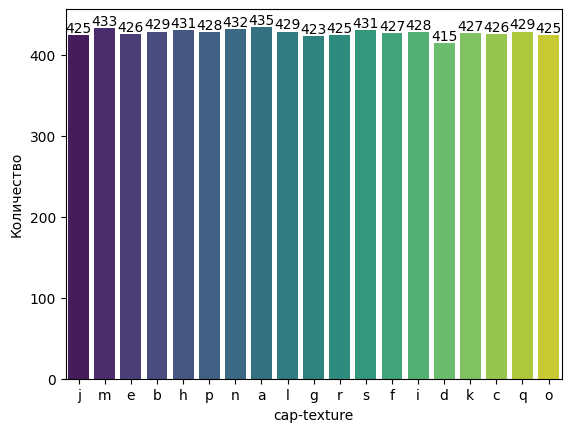

In [10]:
# Распределение cap-texture
countplot_func(mushroom_data, 'cap-texture')

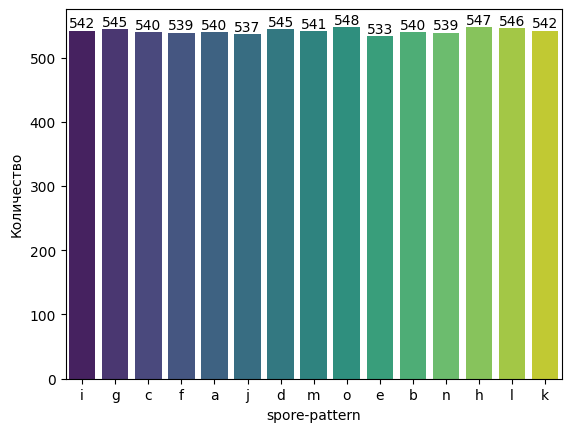

In [11]:
# Распределение spore-pattern
countplot_func(mushroom_data, 'spore-pattern')

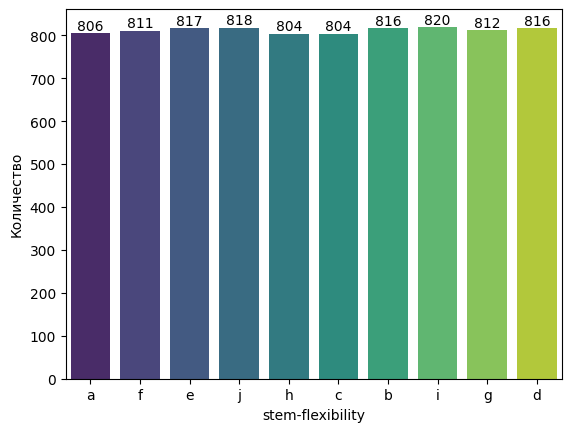

In [12]:
# Распределение stem-flexibility
countplot_func(mushroom_data, 'stem-flexibility')

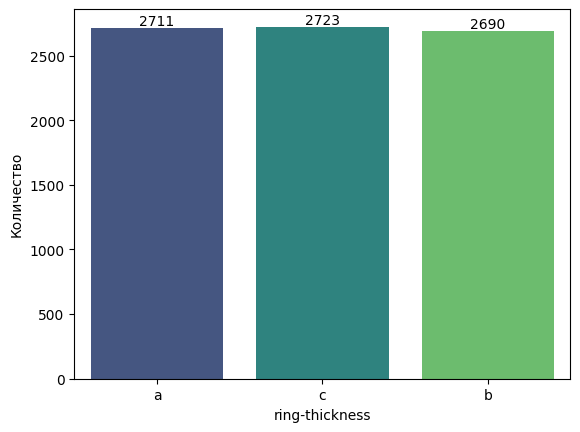

In [13]:
# Распределение ring-thickness
countplot_func(mushroom_data, 'ring-thickness')

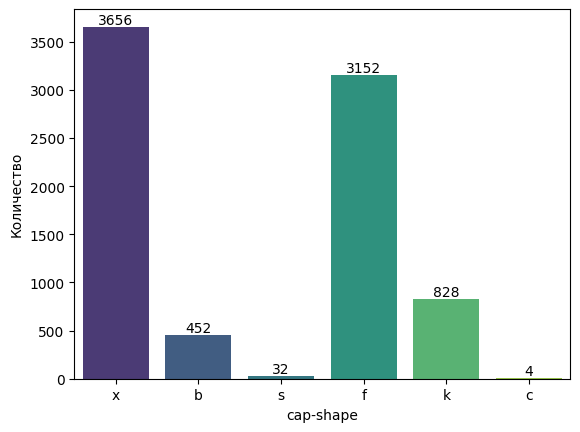

In [14]:
# Распределение cap-shape
countplot_func(mushroom_data, 'cap-shape')

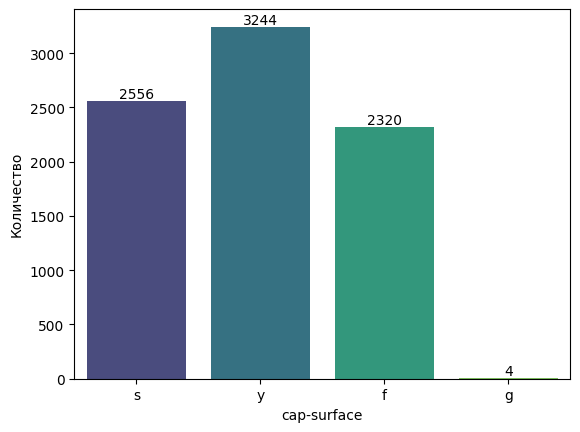

In [15]:
# Распределение cap-surface
countplot_func(mushroom_data, 'cap-surface')

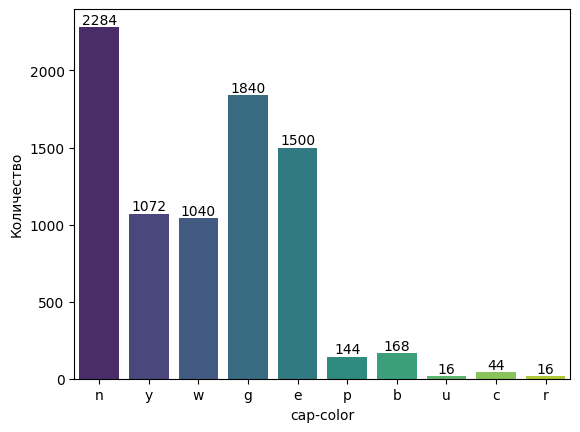

In [16]:
# Распределение cap-color
countplot_func(mushroom_data, 'cap-color')

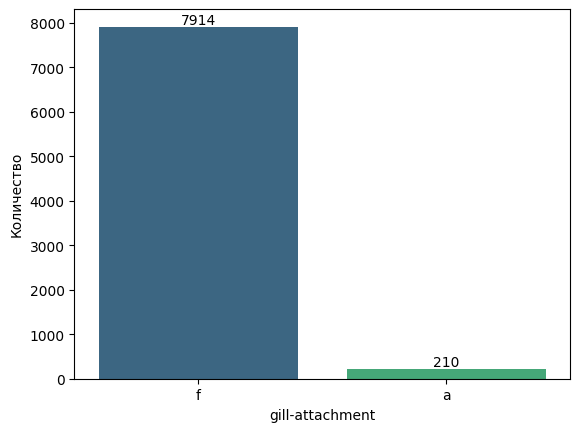

In [17]:
# Распределение gill-attachment
countplot_func(mushroom_data, 'gill-attachment')

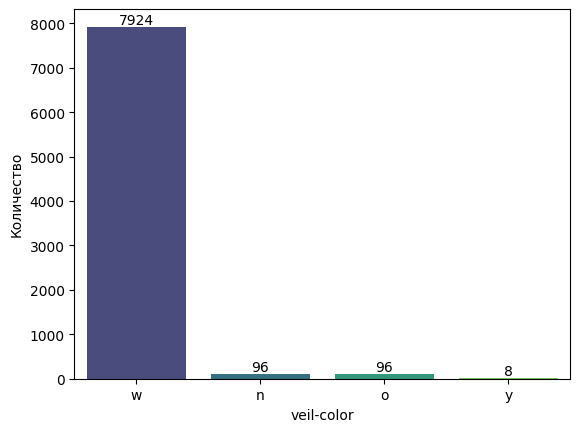

In [18]:
# Распределение veil-color
countplot_func(mushroom_data, 'veil-color')

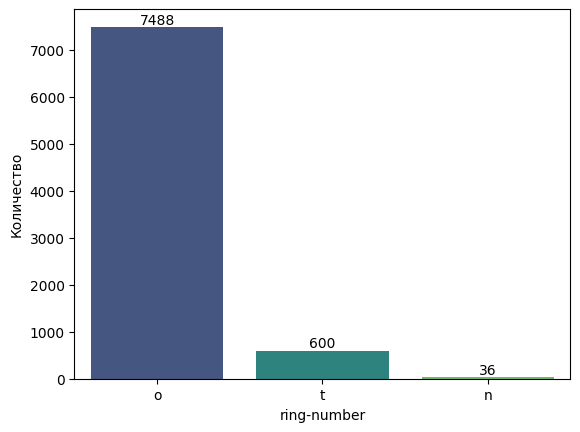

In [19]:
# Распределение ring-number
countplot_func(mushroom_data, 'ring-number')

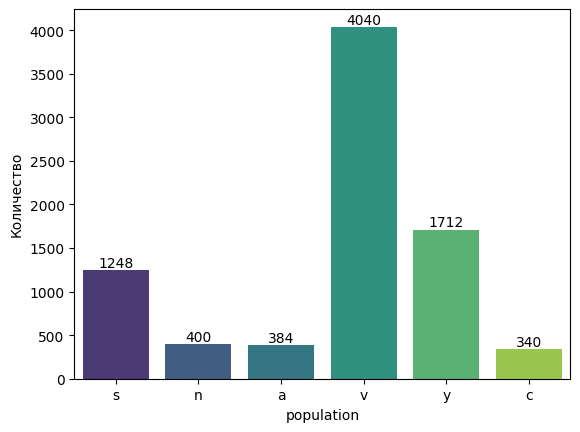

In [20]:
# Распределение population	
countplot_func(mushroom_data, 'population')

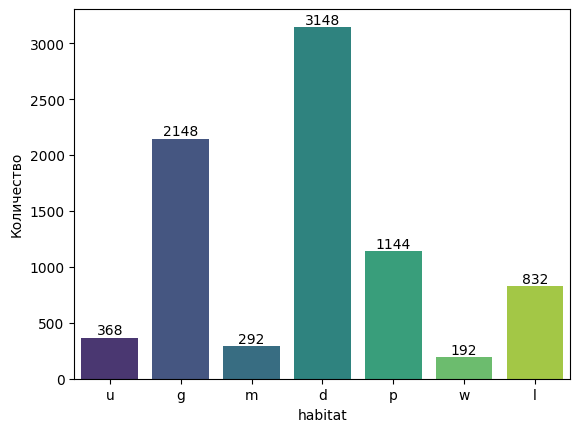

In [21]:
# Распределение habitat
countplot_func(mushroom_data, 'habitat')

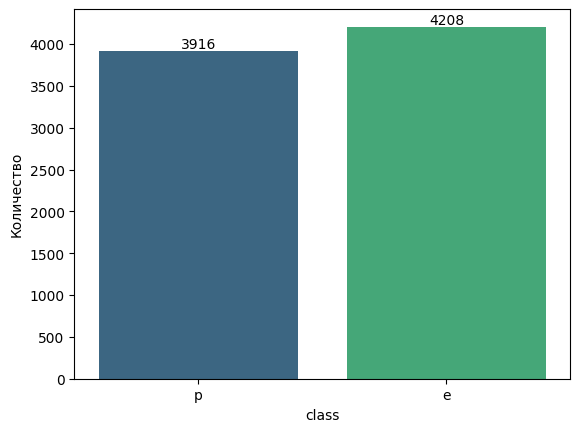

In [22]:
# Распределение class
countplot_func(mushroom_data, 'class')

**Вывод:**  
1 Удалён неинформативный столбец veil-type, содержащий только одну категорию.  
2 Выявлен скрытый пропуск по столбцу ring-number и заполнен медианным значением.    
3 По таргету существенный дисбаланс классов отсутствует.  
4 В датасете наблюдается существенная неравномерность распределения записей по классам признаков: cap-shape, cap-surface, cap-color, gill-attachment, veil-color, ring-number, population, habitat.    
5 Могло бы быть целесообразным сгруппировать малочисленные классы некоторых признаков, т.к. малочисленные классы признаков не представляют ценности для повышения предсказательных возможностей модели. Однако, для этого требуются экспертные знания в микологии, которые позволили бы гарантировано избежать объединения разнородных классов.

## Задание 3

Проверим корреляции между признаками и таргетом:
* Так как данные состоят только из категориальных признаков, в первом приближении можно закодировать их через `OrdinalEncoder`.
* Выберите тип корреляции, которую будете рассчитывать из тех, что мы изучали, с учетом типов признаков.
* Визуализируйте матрицу корреляций на тепловой карте для наглядности. Что можно по ней сказать?

Как всегда, запишите все наблюдения в выводе.

In [23]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Применение OrdinalEncoder ко всему датасету
ordinal_enc = preprocessing.OrdinalEncoder()
mushroom_arr = ordinal_enc.fit_transform(mushroom_data[column_names])

mushroom_df = pd.DataFrame(
    mushroom_arr,
    columns=column_names,
    index=mushroom_data.index
)

In [24]:
# Коэффициенты V Крамера

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()

    r, k = ct.shape
    phi2 = chi2 / n

    phi2_corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)

    return np.sqrt(phi2_corr / max(1, min(r_corr - 1, k_corr - 1)))


def cramers_v_matrix(df):
    cols = df.columns
    corr = pd.DataFrame(
        np.eye(len(cols)),
        index=cols,
        columns=cols
    )

    for i, col1 in enumerate(cols):
        for j in range(i + 1, len(cols)):
            value = cramers_v(df[col1], df[cols[j]])
            corr.iloc[i, j] = value
            corr.iloc[j, i] = value

    return corr

,cap-texture,spore-pattern,stem-flexibility,ring-thickness,cap-shape,cap-surface,cap-color,gill-attachment,stalk-shape,veil-color,ring-number,population,habitat,class
cap-texture,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.009939,0.021540,0.000000,0.000000
spore-pattern,0.000000,1.000000,0.000000,0.000000,0.020424,0.002440,0.000000,0.025994,0.034966,0.022051,0.000000,0.000000,0.010077,0.000000
stem-flexibility,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.008062,0.000000,0.000000,0.009920,0.000000,0.016425,0.000000,0.019039
ring-thickness,0.000000,0.000000,0.000000,1.000000,0.010461,0.000000,0.003254,0.000000,0.000000,0.000000,0.000000,0.015527,0.005774,0.012429
cap-shape,0.000000,0.020424,0.000000,0.010461,1.000000,0.202242,0.168221,0.152979,0.306100,0.223124,0.197883,0.240074,0.269842,0.244315
cap-surface,0.000000,0.002440,0.000000,0.000000,0.202242,1.000000,0.222841,0.209964,0.076390,0.133014,0.097278,0.260952,0.249577,0.195985
cap-color,0.000000,0.000000,0.008062,0.003254,0.168221,0.222841,1.000000,0.245721,0.594462,0.147231,0.336128,0.304085,0.325199,0.215876
gill-attachment,0.000000,0.025994,0.000000,0.000000,0.152979,0.209964,0.245721,1.000000,0.186154,0.954904,0.203170,0.413336,0.435680,0.128723
stalk-shape,0.000000,0.034966,0.000000,0.000000,0.306100,0.076390,0.594462,0.186154,1.000000,0.180857,0.333270,0.455458,0.417076,0.101414
veil-color,0.000000,0.022051,0.009920,0.000000,0.223124,0.133014,0.147231,0.954904,0.180857,1.000000,0.026509,0.226466,0.270233,0.152213


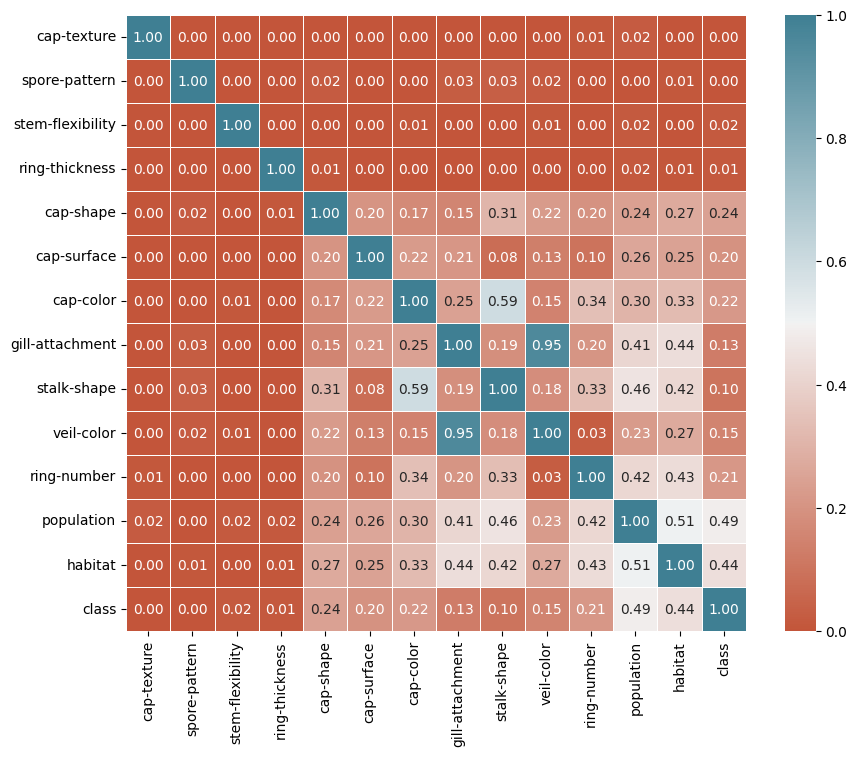

In [25]:
# Матрица коэффициентов
mushroom_corr = cramers_v_matrix(mushroom_df[column_names])
display(mushroom_corr)

# Тепловая карта по матрице коэффициентов
plt.figure(figsize=(10, 8))
sns.heatmap(
    mushroom_corr, 
    annot=True, 
    fmt='.2f', 
    linewidth=.5, 
    cmap=sns.diverging_palette(20, 220, as_cmap=True)
)

plt.show()

**Вывод:**  
1 По тепловой карте наблюдается выраженная корреляция таргета с признаками population (коэффициент 0,49) и habitat (коэффициент 0,44).  
2 По тепловой карте наблюдается наличие слабой связи таргета с признаками (значения коэффициентов около 0,2): cap-shape, cap-color, ring-number, cap-surface.

## Задание 4
Переходим к финальной части — итоговой подготовке данных для подачи на вход моделям:
* Закодируйте категориальные признаки уже подходящим способом, обоснуйте выбор. Сделайте так, чтобы после кодирования получился пандас-датафрейм с понятными названиями столбцов, **избегая утечки данных** между тренировочной и тестовой выборками.
* Не забывайте, что таргет тоже должен быть закодирован.
* Еще раз убедитесь, что удалили/обработали все те неприятности, что выявили ранее, если они остались.
* Разбейте данные на тренировочную, валидационную и тестовую выборки, установите соотношение 80/10/10 и random_state=42.

In [26]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Разделение данных на выборки
X, y = mushroom_data.drop('class', axis=1), mushroom_data['class']

# train и test+val 
X_train, X_temp, y_train, y_temp = model_selection.train_test_split(
    X, y,
    stratify=y, 
    test_size=0.2,
    random_state=42
)

# test и val 
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    stratify=y_temp, 
    test_size=0.5,  
    random_state=42
)

X_train_dict = {}
X_val_dict = {}
X_test_dict = {}

# Список бинарных переменных
binary_lst = ['gill-attachment', 'stalk-shape']

# Переменные, имеющие больше двух категорий
multi_cat_lst = [
    'cap-texture',	'spore-pattern', 'stem-flexibility', 'ring-thickness',
    'cap-shape', 'cap-surface', 'cap-color', 'veil-color', 'ring-number', 
    'population', 'habitat'
]

# Кодирование бинарных переменных
le = preprocessing.LabelEncoder()

for i in binary_lst:
    X_train_dict[i] = le.fit_transform(X_train[i])
    X_val_dict[i] = le.transform(X_val[i])
    X_test_dict[i] = le.transform(X_test[i])

# Кодирование таргета (бинарное)
y_train = le.fit_transform(y_train)
y_train = pd.Series(y_train, index=X_train.index)
y_val = le.transform(y_val)
y_val = pd.Series(y_val, index=X_val.index)
y_test = le.transform(y_test)
y_test = pd.Series(y_test, index=X_test.index)

# Временные датафреймы, в которых собираются
# закодированные признаки
X_train_df = pd.DataFrame(X_train_dict, index=X_train.index)
X_val_df = pd.DataFrame(X_val_dict, index=X_val.index)
X_test_df = pd.DataFrame(X_test_dict, index=X_test.index)


# Переменные, имеющие больше двух категорий
ohe = preprocessing.OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

for i in multi_cat_lst:
    X_train_arr = ohe.fit_transform(X_train[[i]])
    X_val_arr = ohe.transform(X_val[[i]])
    X_test_arr = ohe.transform(X_test[[i]])
    ohe_columns = ohe.get_feature_names_out([i])

    # Добавление во временные датафреймы результатов
    # после применения OneHotEncoder к каждому из признаков
    X_train_temp_df = pd.DataFrame(
    X_train_arr,
    columns=ohe_columns,
    index=X_train.index
    ) 
    X_train_df = pd.concat([X_train_df, X_train_temp_df], axis=1)

    X_val_temp_df = pd.DataFrame(
    X_val_arr,
    columns=ohe_columns,
    index=X_val.index
    ) 
    X_val_df = pd.concat([X_val_df, X_val_temp_df], axis=1)

    X_test_temp_df = pd.DataFrame(
    X_test_arr,
    columns=ohe_columns,
    index=X_test.index
    ) 
    X_test_df = pd.concat([X_test_df, X_test_temp_df], axis=1)


X_train, X_val, X_test = X_train_df, X_val_df, X_test_df  
print('Размеры выборок')
print('Train:', X_train.shape)
print('Val:', X_val.shape)
print('Test:', X_test.shape, '\n')

print('Распределение таргета в выборках')
print(
    'Обучающая выборка:\n', y_train.value_counts(normalize=True), 
    '\n', sep=''
)
print(
    'Валидационная выборка:\n', y_val.value_counts(normalize=True), 
    '\n', sep=''
)
print(
    'Тестовая выборка:\n', 
    y_test.value_counts(normalize=True), 
    '\n', sep=''
)

Размеры выборок
Train: (6499, 89)
Val: (813, 89)
Test: (812, 89) 

Распределение таргета в выборках
Обучающая выборка:
0    0.517926
1    0.482074
Name: proportion, dtype: float64

Валидационная выборка:
0    0.517835
1    0.482165
Name: proportion, dtype: float64

Тестовая выборка:
0    0.518473
1    0.481527
Name: proportion, dtype: float64



**Вывод:**  
1 Таргет и бинарные переменные gill-attachment и stalk-shape были закодированы методом LabelEncoder.  
2 Остальные категориальные переменные, имеющие более двух классов, были закодированы методом OneHotEncoder.

## Задание 5
Приступаем к моделированию. Прежде чем обучать модели, важно определиться с метриками качества. Подумайте, какие аспекты качества модели важны в данной задаче, и запишите рассуждения:
* На какую метрику вы бы ориентировались при сравнении разных моделей между собой?
* Какую метрику или набор метрик вы бы выбрали для презентации результатов бизнесу, учитывая практические ограничения и последствия ошибок модели?

**Вывод:**  
1 Сранение различных моделей между собой будет выполняться по метрике ROC-AUC. Данная метрика эффективна для анализа моделей, т.к. она оценивает качество ранжирования, а не конкретные предсказания. Т.е. сравнение ROC-AUC позволит показать насколько хорошо модели различают классы, независимо от выбранной пороговой вероятности.    
2 Для представления бизнесу метрика качества модели должна быть легко интерпретируемой и при этом отражать уровень функциональных возможностей модели. Учитывая весомость неблагоприятных последствий ошибок модели в данной задаче, в качестве такой метрики может быть применена полнота предсказаний модели (recall). Данная метрика характеризует вероятность ошибки второго рода. Т.е. максимизация метрики приводит непосредственно к снижению вероятности ошибки второго рода (вероятности ложноотрицательных предсказаний). 

## Задание 6
Теперь попробуйте на дефолтных гиперпараметрах (или, по крайней мере, без особого подбора) обучить следующие модели:
* градиентный бустинг, реализованный вручную;
* `GradientBoostingClassifier` из `sklearn`.

Рассчитайте выбранные метрики на тренировочной и тестовой выборке (возьмите для дальнейшего единообразия именно тестовую, валидационную пока оставьте). Что можно сказать о качестве и недо-/переобучении? Замерьте также время работы моделей (обучения и инференса).

In [27]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Градиентный бустинг, реализованный вручную

class SimpleGradientBoostingClassifier:
    """
    Реализация градиентного бустинга.
    """

    def __init__(
        self, 
        learning_rate: float=0.1,
        n_estimators: int=100,
        min_samples_leaf: int=1,
        max_depth: int=3,
        random_state: int=42
    ):
        """
        Args:
            learning_rate (float): скорость обучения.
            n_estimators (int): количество деревьев.
            min_samples_leaf (int): минимальное количество записей в листе.
            max_depth (int): максимальная глубина каждого дерева.
        """

        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.random_state = random_state

        # Будет заполнено в fit()
        self.model_ = None 

    def _sigmoid(self, x: np.ndarray) -> np.ndarray:
        """Сигмоида (элементно)."""
        return 1.0 / (1.0 + np.exp(-x))
    
    def _init_F0(self, y: np.ndarray) -> float:
        """Вычислить начальный F0 = logit(mean(y)) с клиппингом."""
        eps = 1e-6
        p0 = np.clip(np.mean(y), eps, 1 - eps)
        return np.log(p0 / (1 - p0))


    def fit(self, X: pd.DataFrame, y: pd.Series):
        """
        Обучение модели.
        """
        X_arr = np.asarray(X)
        y_arr = np.asarray(y)

        F0 = self._init_F0(y_arr)
        F = np.full(len(y_arr), fill_value=F0, dtype=float)

        trees = []
        for estimator in range(self.n_estimators):
            p = self._sigmoid(F)               
            residual = y_arr - p         

            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                random_state=self.random_state
            )
            tree.fit(X_arr, residual)  
            update = tree.predict(X_arr)
            
            F = F + self.learning_rate*update

            trees.append(tree)

        self.model_ = {
            "F0": float(F0),
            "trees": trees,
            "learning_rate": float(self.learning_rate)
        }

        return self

    def _decision_function(self, X: pd.DataFrame) -> np.ndarray:
        """
        Возвращает сырые предсказания F (логиты).
        """
        X_arr = np.asarray(X)
        F = np.full(X_arr.shape[0], fill_value=self.model_["F0"], dtype=float)
        for tree in self.model_["trees"]:
            F += self.model_["learning_rate"] * tree.predict(X_arr)
        return F

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """
        Возвращает массив shape=(n_samples, 2): [prob(0), prob(1)].
        """
        F = self._decision_function(X)
        p = self._sigmoid(F)
        return np.vstack([1 - p, p]).T

    def predict(self, X: pd.DataFrame, threshold: float = 0.5) -> np.ndarray:
        """Классы 0/1 по порогу."""
        probs = self.predict_proba(X)[:, 1]
        return (probs >= threshold).astype(int)

In [28]:
%%time

manual_GBC = SimpleGradientBoostingClassifier(random_state=42)
manual_GBC.fit(X_train, y_train)
y_pred_test = manual_GBC.predict(X_test)

CPU times: user 755 ms, sys: 6.68 ms, total: 762 ms
Wall time: 745 ms


In [29]:
# Результаты градиентного бустинга, реализованного вручную
y_pred_train = manual_GBC.predict(X_train)
probs_train = manual_GBC.predict_proba(X_train)[:, 1]
print('Метрики для обучающей выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_train, probs_train))
print('Полнота:', metrics.recall_score(y_train, y_pred_train))

probs_test = manual_GBC.predict_proba(X_test)[:, 1]
print('Метрики для тестовой выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_test, probs_test))
print('Полнота:', metrics.recall_score(y_test, y_pred_test))

Метрики для обучающей выборки:
ROC_AUC_score: 0.9600019553033955
Полнота: 0.8729652090647941
Метрики для тестовой выборки:
ROC_AUC_score: 0.960989848795038
Полнота: 0.8618925831202046


In [30]:
%%time

sklearn_GBC = GradientBoostingClassifier(random_state=42)
sklearn_GBC.fit(X_train, y_train)
y_pred_test = sklearn_GBC.predict(X_test)

CPU times: user 631 ms, sys: 2.27 ms, total: 634 ms
Wall time: 620 ms


In [31]:
# Результаты градиентного бустинга из sklearn
y_pred_train = sklearn_GBC.predict(X_train)
probs_train = sklearn_GBC.predict_proba(X_train)[:, 1]
print('Метрики для обучающей выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_train, probs_train))
print('Полнота:', metrics.recall_score(y_train, y_pred_train))

probs_test = sklearn_GBC.predict_proba(X_test)[:, 1]
print('Метрики для тестовой выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_test, probs_test))
print('Полнота:', metrics.recall_score(y_test, y_pred_test))

Метрики для обучающей выборки:
ROC_AUC_score: 0.9869890774211009
Полнота: 0.9275454835620811
Метрики для тестовой выборки:
ROC_AUC_score: 0.9860823395763345
Полнота: 0.9207161125319693


**Вывод:**  
1 Модель GradientBoostingClassifier из sklearn показала на тестовой выборке большую точность по метрике ROC_AUC: 0,986 против 0,961 у ручной реализации. Данный результат обеспечил лучшее качество модели из sklearn по метрике полноты (recall): 0,921 против 0,862.  
2 Обе модели показывают очень высокое качество по метрике ROC_AUC. У каждой из моделей разница в результатах для тренировочной и тестовой выборки невелика, что говорит об отсутствии сильного переобучения.  
3 Время работы моделей оказалось практически одинаковым (Wall time): 745 и 620 мс.

## Задание 7
Теперь попробуйте на дефолтных гиперпараметрах обучить трех китов современных градиентных бустингов:
* CatBoost;
* XGBoost;
* LightGBM.

Также замерьте качество и время работы (обучения и инференса), сделайте итоговый вывод. Какую модель рекомендовали бы для продакшена?

In [32]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Пулы для CatBoostClassifier
train_pool = cb.Pool(
    X_train,
    label=y_train
)
valid_pool = cb.Pool(
    X_val,
    label=y_val
)
test_pool = cb.Pool(
    X_test,
    label=y_test
)

In [33]:
%%time

model_CBC = cb.CatBoostClassifier(
    verbose=0, random_seed=42
)

model_CBC.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)
y_pred_test = model_CBC.predict(test_pool)

CPU times: user 19.2 s, sys: 30.5 s, total: 49.7 s
Wall time: 4.3 s


In [34]:
# Результаты CatBoost
y_pred_train = model_CBC.predict(train_pool)
probs_train = model_CBC.predict_proba(train_pool)[:, 1]
print('Метрики для обучающей выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_train, probs_train))
print('Полнота:', metrics.recall_score(y_train, y_pred_train))

probs_test = model_CBC.predict_proba(test_pool)[:, 1]
print('Метрики для тестовой выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_test, probs_test))
print('Полнота:', metrics.recall_score(y_test, y_pred_test))

Метрики для обучающей выборки:
ROC_AUC_score: 0.9998130039623816
Полнота: 0.984360038301947
Метрики для тестовой выборки:
ROC_AUC_score: 0.9955653024402987
Полнота: 0.9360613810741688


In [35]:
# Матрицы для XGBoost

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# Cетка гиперпараметров (по семинарскому ноутбуку)
xgb_params = {
    'max_depth': 6,            # максимальная глубина дерева
    'eta': 0.1,                # learning rate, шаг обновления весов
    'subsample': 0.8,          # доля объектов, используемых для каждого дерева
    'colsample_bytree': 0.8,   # доля признаков, используемых при построении дерева
    'gamma': 0,                # минимальное снижение функции потерь для разбиения (больше gamma -> меньше переобучение)
    'alpha': 0,                # l1-регуляризация весов листьев
    'lambda': 1,               # l2-регуляризация весов листьев
    'objective': 'binary:logistic',  # функция потерь (здесь - для бинарной классификации)
    'eval_metric': 'auc',      # метрика качества на валидации
    'seed': 42                 # фиксирует воспроизводимость
}

In [36]:
%%time

model_XGB = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    evals=[(dtrain, 'train'), (dval, 'valid')],
    verbose_eval=0
)
probs_test = model_XGB.predict(dtest)

CPU times: user 1.19 s, sys: 17.3 ms, total: 1.21 s
Wall time: 90.1 ms


In [37]:
# Результаты XGBoost
probs_train = model_XGB.predict(dtrain)
y_pred_train = (probs_train >= 0.5).astype(int)

print('Метрики для обучающей выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_train, probs_train))
print('Полнота:', metrics.recall_score(y_train, y_pred_train))

y_pred_test = (probs_test >= 0.5).astype(int)
print('Метрики для тестовой выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_test, probs_test))
print('Полнота:', metrics.recall_score(y_test, y_pred_test))

Метрики для обучающей выборки:
ROC_AUC_score: 0.9913564590157219
Полнота: 0.921481008617938
Метрики для тестовой выборки:
ROC_AUC_score: 0.9892413022216012
Полнота: 0.9104859335038363


In [38]:
# Датасеты для LightGBM
lgb_train = lgb.Dataset(
    X_train,
    label=y_train
)
lgb_valid = lgb.Dataset(
    X_val,
    label=y_val,
    reference=lgb_train
)
lgb_test = lgb.Dataset(
    X_test,
    label=y_test,
    reference=lgb_train
)

# Cетка гиперпараметров (по семинарскому ноутбуку)
lgb_params = {
    # === ВАРИАНТ ДЛЯ dart ===
    # 'boosting_type': 'dart',      # dropout boosting

    # # dart-специфичные параметры
    # 'drop_rate': 0.1,             # доля "выключаемых" деревьев
    # 'skip_drop': 0.5,             # вероятность пропустить dropout
    # 'max_drop': 50,               # максимум деревьев для дропа
    # ========================

    # базовая логика бустинга
    'boosting_type': 'gbdt',         # классический gradient boosting decision trees
    'objective': 'binary',           # бинарная классификация
    'metric': 'auc',                 # метрика качества

    # включаем extra trees режим (для 'boosting_type': 'gbdt')
    'extra_trees': True,             # случайный выбор порогов (меньше переобучение)

    # сложность модели
    'num_leaves': 31,                # число листьев (главный параметр сложности)
    'max_depth': -1,                 # ограничение глубины (-1 = без ограничения)
    'learning_rate': 0.05,           # шаг обучения

    # контроль разбиений
    'min_child_samples': 20,         # минимальное число объектов в листе
    'min_child_weight': 1e-3,        # минимальная сумма hessian в листе
    'min_split_gain': 0.0,           # минимальный прирост качества для сплита

    # стохастичность
    'subsample': 0.8,                # доля объектов для дерева
    'subsample_freq': 1,             # как часто применять subsample
    'feature_fraction': 0.8,         # доля признаков для дерева

    # регуляризация
    'lambda_l1': 0.5,                # l1-регуляризация
    'lambda_l2': 1.0,                # l2-регуляризация

    # ускорение
    'max_bin': 255,                  # число бинов для гистограмм
    'n_jobs': -1,                    # использовать все ядра

    # воспроизводимость
    'seed': 42,
    'verbosity': -1                  # отключить лишние логи
}

In [39]:
%%time

model_LGB = lgb.train(
    params=lgb_params,
    train_set=lgb_train,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=['train', 'valid']
)
probs_test = model_LGB.predict(X_test)

CPU times: user 1min 6s, sys: 0 ns, total: 1min 6s
Wall time: 4.4 s


In [40]:
# Результаты LightGBM
probs_train = model_LGB.predict(X_train)
y_pred_train = (probs_train >= 0.5).astype(int)

print('Метрики для обучающей выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_train, probs_train))
print('Полнота:', metrics.recall_score(y_train, y_pred_train))

y_pred_test = (probs_test >= 0.5).astype(int)
print('Метрики для тестовой выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_test, probs_test))
print('Полнота:', metrics.recall_score(y_test, y_pred_test))

Метрики для обучающей выборки:
ROC_AUC_score: 0.9958111749666546
Полнота: 0.9339291413980211
Метрики для тестовой выборки:
ROC_AUC_score: 0.9950732332590166
Полнота: 0.9309462915601023


**Вывод:**  
1 Все три модели (CatBoost, XGBoost, LightGBM) на тестовой выборке по метрике ROC_AUC превосходят результат, полученный GradientBoostingClassifier из sklearn. ROC_AUC этих трёх моделей на тестовой выборке состави соответственно: 0,9956, 0,9892, 0,9951.  
2 Наибольшую точность по метрике ROC_AUC показала модель CatBoost. Этой моделью также обеспечивается и наибольшая полнота 0,936. Поэтому для продакшена рекомендуется модель CatBoost.     
3 Наибольшим быстродействием обладает модель XGBoost - Wall time 90 мс. Наименьшую скорость работы показала модель LightGBM - Wall time 4.4 с.  

## Задание 8
Итак, мы выбрали лучшую архитектуру модели. Попробуем улучшить ее предсказание, подобрав более точные значения гиперпараметров (не менее пяти). Можете воспользоваться любой библиотекой/инструментом (главное, не в цикле и не вручную). Оптимизируйтесь под целевую метрику. Удалось ли улучшить ее значение?

In [41]:
"""
ВАШЕ РЕШЕНИЕ
"""

def objective(trial) -> float:
    """
    Функция для оптимизации CatBoostClassifier по 
    метрике roc_auc_score.
    """
    # Оптимизируемые гиперпараметры
    params = {
        'depth': trial.suggest_int('depth', 1, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.5),
        'iterations': 1000,
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.5, 10),
        'random_seed': 42,
        'eval_metric': 'AUC',
        'use_best_model': True,
        'verbose': 0, 
        'border_count': trial.suggest_int('border_count', 32, 255),   # для числовых фич
        'bagging_temperature': trial.suggest_uniform('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_uniform('random_strength', 0, 10)
    }

    model = cb.CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=valid_pool)

    valid_pred = model.predict_proba(valid_pool)[:, 1]
    auc = metrics.roc_auc_score(y_val, valid_pred)

    return auc

In [42]:
# Поиск лучших параметров
sampler = TPESampler(seed=43) 
study = optuna.create_study(sampler=sampler, direction='maximize')
study.optimize(objective, n_trials=50, timeout=1800) 

# Лучшие параметры
print("Лучший ROC_AUC_score на валидационной выборке:", end=' ')
print(study.best_value)
print("Лучшие гиперпараметры:")
print(
    *(f'{key} = {value}' for key, value in study.best_params.items()), 
    sep='\n'
)

[I 2026-03-15 08:55:54,430] A new study created in memory with name: no-name-022fcedf-3fcf-4d68-8bfb-165b3a69d3d3
[I 2026-03-15 08:55:57,350] Trial 0 finished with value: 0.9941768869067817 and parameters: {'depth': 2, 'learning_rate': 0.1083392390509115, 'l2_leaf_reg': 0.7456167399989247, 'border_count': 85, 'bagging_temperature': 0.3271390558111398, 'random_strength': 8.591374909485976}. Best is trial 0 with value: 0.9941768869067817.
[I 2026-03-15 08:56:02,466] Trial 1 finished with value: 0.9948676620291822 and parameters: {'depth': 7, 'learning_rate': 0.08306505675639593, 'l2_leaf_reg': 0.54540342415084, 'border_count': 196, 'bagging_temperature': 0.39495001843100586, 'random_strength': 8.020471186286665}. Best is trial 1 with value: 0.9948676620291822.
[I 2026-03-15 08:56:05,668] Trial 2 finished with value: 0.9895717194241116 and parameters: {'depth': 3, 'learning_rate': 0.012492397681840163, 'l2_leaf_reg': 6.706653697662967, 'border_count': 81, 'bagging_temperature': 0.40498944

Лучший ROC_AUC_score на валидационной выборке: 0.9955644965824809
Лучшие гиперпараметры:
depth = 4
learning_rate = 0.14426903489208018
l2_leaf_reg = 0.7800985529013594
border_count = 103
bagging_temperature = 0.47781817497692847
random_strength = 0.6401381492117277


In [43]:
# Обучение модели на лучших гиперпараметрах

# Оптиммальный набор параметров
params = {
    'depth': 4,
    'learning_rate': 0.14426903489208018,
    'iterations': 1000,
    'l2_leaf_reg': 0.7800985529013594,
    'random_seed': 42,
    'eval_metric': 'AUC',
    'use_best_model': True,
    'verbose': 0, 
    'border_count': 103,   # для числовых фич
    'bagging_temperature': 0.47781817497692847,
    'random_strength': 0.6401381492117277
}

model_CBC = cb.CatBoostClassifier(**params)
model_CBC.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

y_pred_train = model_CBC.predict(train_pool)
probs_train = model_CBC.predict_proba(train_pool)[:, 1]
print('Метрики для обучающей выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_train, probs_train))
print('Полнота:', metrics.recall_score(y_train, y_pred_train))

y_pred_test = model_CBC.predict(test_pool)
probs_test = model_CBC.predict_proba(test_pool)[:, 1]
print('Метрики для тестовой выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_test, probs_test))
print('Полнота:', metrics.recall_score(y_test, y_pred_test))

Метрики для обучающей выборки:
ROC_AUC_score: 0.9972092358594676
Полнота: 0.940312799233961
Метрики для тестовой выборки:
ROC_AUC_score: 0.9966527145816502
Полнота: 0.9335038363171355


**Вывод:**  
1 Модель CatBoost оптимизировалась по гиперпараметрам: depth, learning_rate, l2_leaf_reg, border_count, bagging_temperature, random_strength.    
2 Найденый оптимальный набор значений гиперпараметров обеспечил дальнейшую максимизацию качества модели по ROC_AUC. На тестовой выборке эта метрика возрасла с 0,9956 до 0,9967. Однако, при этом на тестовой выборке несколько снизилась метрика полноты: было - 0,9361, стало - 0,9335.

## Задание 9
Теперь интерпретируем модель, посмотрев на важность признаков. Согласуются ли результаты с предположениями из 3-го задания?

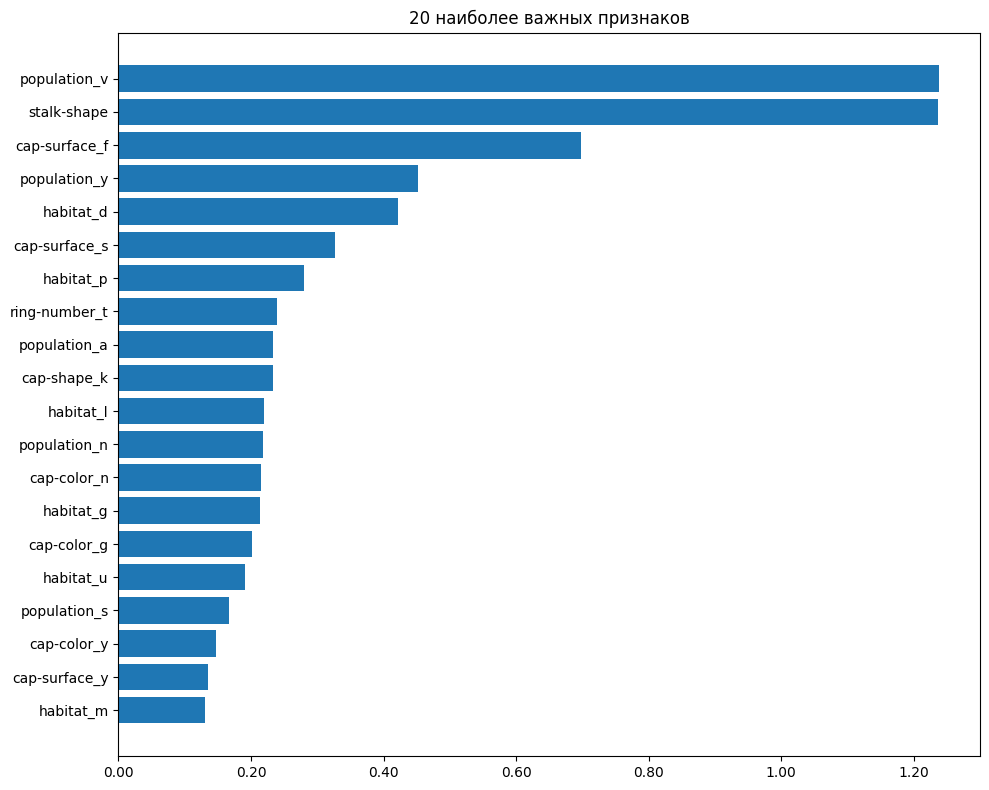

In [44]:
"""
ВАШЕ РЕШЕНИЕ
"""

# SHAP значения для тестовой выборки
shap_values = model_CBC.get_feature_importance(
    type='ShapValues',
    data=test_pool
)
# SHAP значения признаков
shap_values = shap_values[:, :-1]
# Усреднение по записям
importances = np.abs(shap_values).mean(axis=0)

# Вывод столбчатой диаграммы признаков
feature_names = X_test.columns

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(fi['feature'], fi['importance'])
plt.gca().invert_yaxis()

plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.title("20 наиболее важных признаков")
plt.tight_layout()
plt.show()

**Вывод:**  
1 По SHAP-значениям наибольшую важность показал бинарный признак stalk-shape, а также отдельные категории признаков population (population_v, population_y), cap-surface (cap-surface_f, cap-surface_s) и habitat (habitat_d, habitat_p).  
2 Данные результаты согласуются с полученными в третьем задании в части признаков population и habitat, где для этих признаков также были получены наибольши коэффициенты.  
3 С другой стороны, по SHAP-значениям была выявлена высокая важность признака stalk-shape, которая на тепловой карте в задании три не наблюдалась.  

## Задание 10*
Проведите отбор признаков встроенными методами библиотеки `CatBoost`:
* Выполните кодирование категориальных признаков через встроенный в `CatBoost` target encoding.
* Через метод `select_features` отберите оптимальное число признаков, визуализируйте процесс.
* Обучите алгоритм `CatBoost` на отобранных признаках и с target encoding. Удалось ли ускорить время работы алгоритма (обучения и инференса) и улучшить качество?

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Step #1 out of 1

bestTest = 0.9946677008
bestIteration = 107

Shrink model to first 108 iterations.
Feature #1 eliminated
Feature #7 eliminated
Feature #0 eliminated
Feature #3 eliminated
Feature #2 eliminated
Feature #9 eliminated
Feature #4 eliminated
Feature #10 eliminated
Train final model

bestTest = 0.9918561249
bestIteration = 696

Shrink model to first 697 iterations.


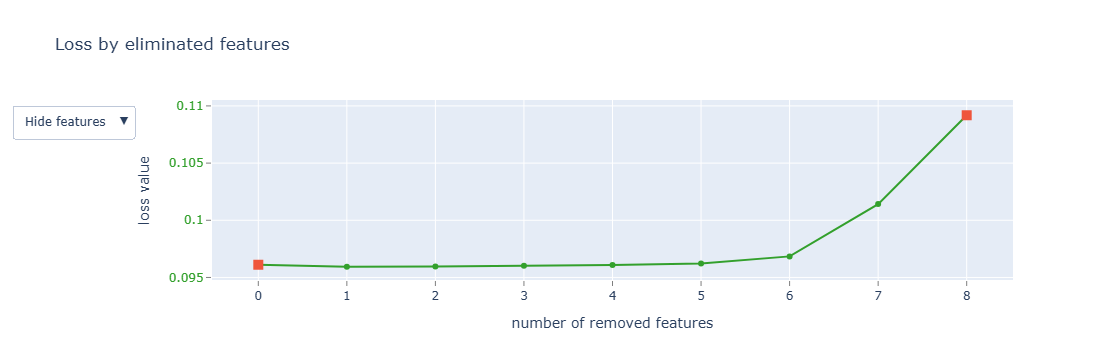

In [45]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Выборки без кодирования признаков
# train и test+val 
X_train_CBC, X_temp_CBC, y_train_CBC, y_temp_CBC = (
    model_selection.train_test_split(
        X, y,
        stratify=y, 
        test_size=0.2,
        random_state=42
    )
)
    
# test и val 
X_test_CBC, X_val_CBC, y_test_CBC, y_val_CBC = train_test_split(
    X_temp_CBC, y_temp_CBC,
    stratify=y_temp_CBC, 
    test_size=0.5,  
    random_state=42
)

# Пулы для CatBoostClassifier
categorical_features = X_train_CBC.select_dtypes(
    include=['str']
).columns.tolist()
train_pool_tg_enc = cb.Pool(
    X_train_CBC,
    y_train_CBC,
    cat_features=categorical_features
)
valid_pool_tg_enc = cb.Pool(
    X_val_CBC,
    y_val_CBC,
    cat_features=categorical_features
)
test_pool_tg_enc = cb.Pool(
    X_test_CBC,
    y_test_CBC,
    cat_features=categorical_features
)

# Инициализация модели
params = {
    'depth': 4,
    'learning_rate': 0.14426903489208018,
    'iterations': 1000,
    'l2_leaf_reg': 0.7800985529013594,
    'random_seed': 42,
    'eval_metric': 'AUC',
    'use_best_model': True,
    'verbose': 0, 
    'border_count': 103,   # для числовых фич
    'bagging_temperature': 0.47781817497692847,
    'random_strength': 0.6401381492117277
}
model_CBC = cb.CatBoostClassifier(**params)

# Построение кривой loss для выявления 
# оптимального количества признаков
summary = model_CBC.select_features(
    train_pool_tg_enc,
    eval_set=valid_pool_tg_enc,
    features_for_select="0-{}".format(X_train_CBC.shape[1] - 1),
    num_features_to_select=5,
    steps=1,
    algorithm="RecursiveByShapValues",
    shap_calc_type="Regular",
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Step #1 out of 1

bestTest = 0.9946677008
bestIteration = 107

Shrink model to first 108 iterations.
Feature #1 eliminated
Feature #7 eliminated
Feature #0 eliminated
Feature #3 eliminated
Feature #2 eliminated
Train final model

bestTest = 0.9951463959
bestIteration = 89

Shrink model to first 90 iterations.


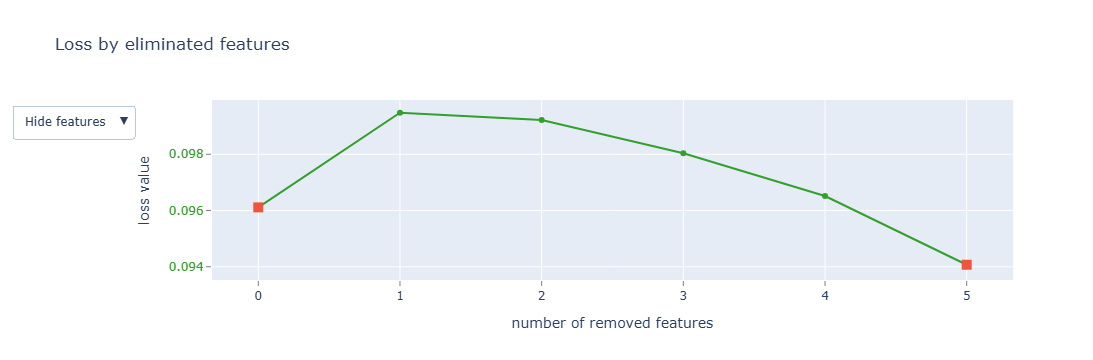

Отобранные признаки:
cap-shape, cap-surface, cap-color, stalk-shape, veil-color, ring-number, population, habitat


In [46]:
# Инициализация модели
params = {
    'depth': 4,
    'learning_rate': 0.14426903489208018,
    'iterations': 1000,
    'l2_leaf_reg': 0.7800985529013594,
    'random_seed': 42,
    'eval_metric': 'AUC',
    'use_best_model': True,
    'verbose': 0, 
    'border_count': 103,   # для числовых фич
    'bagging_temperature': 0.47781817497692847,
    'random_strength': 0.6401381492117277
}
model_CBC = cb.CatBoostClassifier(**params)

# Отбор оптимального числа признаков
summary = model_CBC.select_features(
    train_pool_tg_enc,
    eval_set=valid_pool_tg_enc,
    features_for_select="0-{}".format(X_train_CBC.shape[1] - 1),
    num_features_to_select=8,
    steps=1,
    algorithm="RecursiveByShapValues",
    shap_calc_type="Regular",
    plot=True
)

# Отобранные фичи
selected_features = summary["selected_features"]
feature_names = X_train_CBC.columns[selected_features].to_list()
print('Отобранные признаки:')
print(*feature_names, sep=', ')

In [47]:
# Ограничение используемых фичей
X_train_select = X_train_CBC.iloc[:, selected_features]
X_val_select = X_val_CBC.iloc[:, selected_features]
X_test_select  = X_test_CBC.iloc[:, selected_features]

# Пулы для CatBoostClassifier
categorical_features = X_train_select.select_dtypes(
    include=['str']
).columns.tolist()
train_pool_tg_enc = cb.Pool(
    X_train_select,
    y_train_CBC,
    cat_features=categorical_features
)
valid_pool_tg_enc = cb.Pool(
    X_val_select,
    y_val_CBC,
    cat_features=categorical_features
)
test_pool_tg_enc = cb.Pool(
    X_test_select,
    y_test_CBC,
    cat_features=categorical_features
)

In [48]:
%%time

model_CBC.fit(
    train_pool_tg_enc,
    eval_set=valid_pool_tg_enc,
    use_best_model=True
)
y_pred_test = model_CBC.predict(test_pool_tg_enc)

CPU times: user 38.5 s, sys: 38.3 s, total: 1min 16s
Wall time: 5.13 s


In [49]:
# Результаты

y_pred_train = model_CBC.predict(train_pool_tg_enc)

# Кодирование таргета для расчёта метрик
y_train_CBC = le.fit_transform(y_train_CBC)
y_test_CBC = le.transform(y_test_CBC)
y_pred_train = le.transform(y_pred_train)
y_pred_test = le.transform(y_pred_test)
    
probs_train = model_CBC.predict_proba(train_pool_tg_enc)[:, 1]
print('Метрики для обучающей выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_train_CBC, probs_train))
print('Полнота:', metrics.recall_score(y_train_CBC, y_pred_train))

probs_test = model_CBC.predict_proba(test_pool_tg_enc)[:, 1]
print('Метрики для тестовой выборки:')
print('ROC_AUC_score:', metrics.roc_auc_score(y_test_CBC, probs_test))
print('Полнота:', metrics.recall_score(y_test_CBC, y_pred_test))

Метрики для обучающей выборки:
ROC_AUC_score: 0.9955010953302387
Полнота: 0.9320140440472391
Метрики для тестовой выборки:
ROC_AUC_score: 0.9956290891860203
Полнота: 0.9309462915601023


**Вывод:**  
1 Кодирование признаков в задании выполнялось встроенным методом target encoding, поэтому количество признаков относительно исходных, взятых из датасета, не изменялось и составило 13.  
2 Первый запуск метода select_features был выполнен для малого числа сохраняемых признаков (num_features_to_select=5). Это позволило визуализировать влияние на модель исключения существенного числа признаков (8 из 13). Полученный график показал, что по значению loss в модели должно оставаться не менее 8 признаков, а именно: cap-shape, cap-surface, cap-color, stalk-shape, veil-color, ring-number, population, habitat.  
3 Второй запуск метода select_features был выполнен для восьми сохраняемых признаков. Полученный результат подтвердил, что, при исключении пяти признаков, точность модели относительно исходной не снижается.  
4 Результат полученный с использованием встроенного target encoding для восьми отобранных признаков получился хуже, чем для кодирования признаков через LabelEncoder, OneHotEncoder. На тестовой выборке ROC_AUC снизился с 0,9967 до 0.9956. Также произошло дальнейшее снижение полноты - до 0,931.  
5 Снизилось быстродействие модели. Метрика Wall time возрасла до 5,13 с (у дефолтной CatBoost модели было 4,3 с).  
6 Полученные результаты могут указывать на то, что, из-за изменения набора признаков в этом задании, необходимо выполнить повторную оптимизацию гиперпараметров.